#  Customer Retention & Churn Analysis


👤 **Intern:** Ponakarlapalli Bharani  
📅 **Date:** March 2026  

🏢 **Organization:** Future Interns  



##  Objective

The objective of this project is to analyze customer churn patterns, identify key factors affecting customer retention, and provide actionable recommendations to reduce churn in a subscription-based business.**bold text**

In [110]:
import pandas as pd
import matplotlib.pyplot as plt

##  Dataset Loading

In this step, we load the dataset and preview the data.

In [112]:
import pandas as pd

df = pd.read_excel("Telco_customer_churn.xlsx")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


##  Data Understanding

In this step, we explore the dataset to understand its structure, column names, and data types. This helps in identifying important features required for churn analysis.

In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

##  Checking Missing Values

We check for any missing or null values in the dataset to ensure data quality before analysis.

In [114]:
df.isnull().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


##  Removing Duplicates

Duplicate records can affect analysis, so we remove them to maintain data accuracy.

In [115]:
df = df.drop_duplicates()

##  Churn Distribution

We analyze how many customers have churned versus those who are retained.

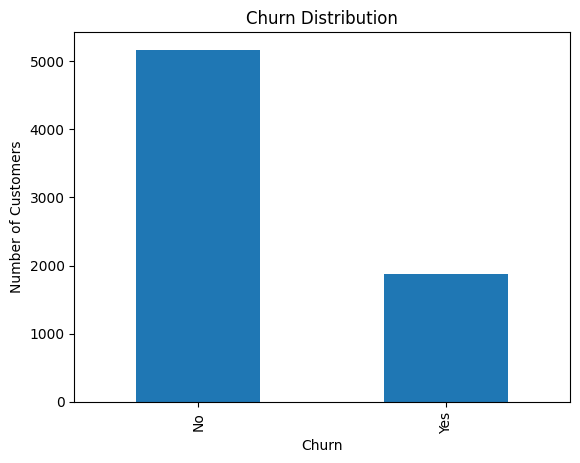

In [116]:
df['Churn Label'].value_counts().plot(kind='bar')
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

##  Churn Percentage

This shows the percentage of customers who have left the service.

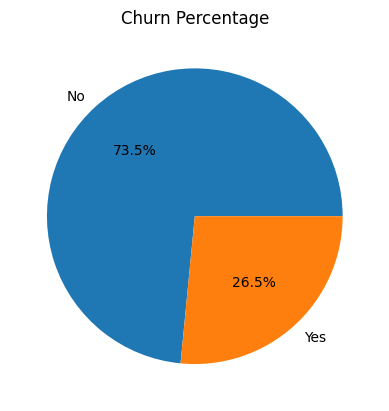

In [117]:
df['Churn Label'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Churn Percentage")
plt.ylabel("")
plt.show()

##  Churn Visualization

We visualize churn distribution using a bar chart.

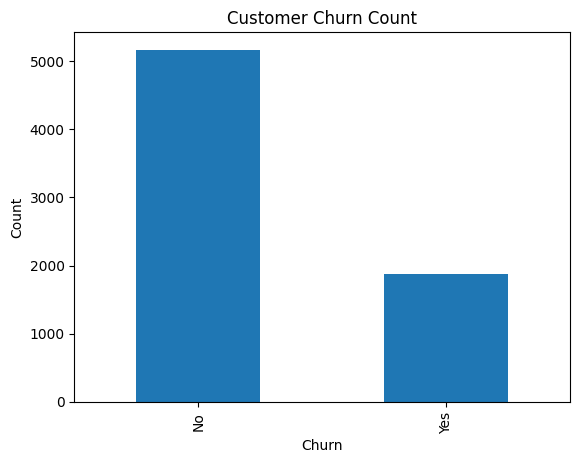

In [118]:
import matplotlib.pyplot as plt

df['Churn Label'].value_counts().plot(kind='bar')
plt.title("Customer Churn Count")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

##  Monthly Charges vs Churn

We analyze how monthly charges impact churn.

In [119]:
df = df.rename(columns={
    'Monthly Charges': 'MonthlyCharges',
    'Tenure Months': 'Tenure'
})

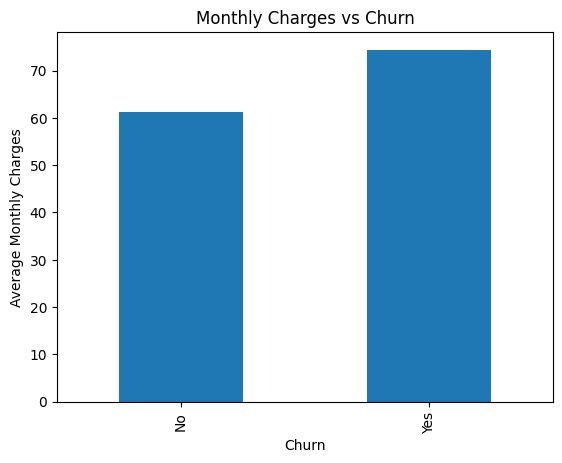

In [120]:
df.groupby('Churn Label')['MonthlyCharges'].mean().plot(kind='bar')
plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Average Monthly Charges")
plt.show()

##  Contract Type vs Churn Analysis

In this section, we analyze how customer churn varies across different contract types such as month-to-month, one-year, and two-year plans. This helps identify which contract types are more prone to customer churn.

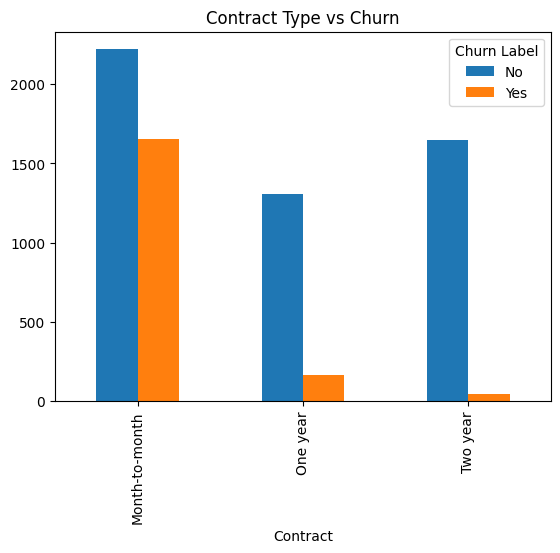

In [121]:
df.groupby(['Contract','Churn Label']).size().unstack().plot(kind='bar')
plt.title("Contract Type vs Churn")
plt.show()

##  Renaming Columns

In this step, we rename column names to remove spaces and improve readability. This makes it easier to write code and reduces the chances of errors during analysis.

In [122]:
df = df.rename(columns={
    'Monthly Charges': 'MonthlyCharges',
    'Tenure Months': 'Tenure'
})

##  Viewing Column Names

In this step, we display all column names in the dataset. This helps us understand the available features and ensures that we use the correct column names during analysis.

In [123]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure', 'Phone Service', 'Multiple Lines',
       'Internet Service', 'Online Security', 'Online Backup',
       'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies',
       'Contract', 'Paperless Billing', 'Payment Method', 'MonthlyCharges',
       'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV',
       'Churn Reason'],
      dtype='object')

##  Tenure Analysis

We analyze how customer duration affects churn.

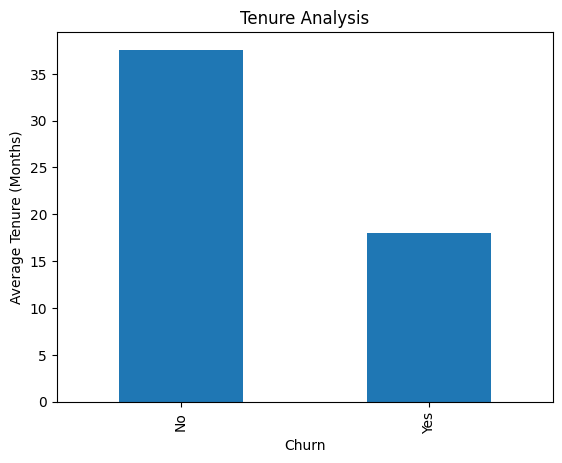

In [124]:
df.groupby('Churn Label')['Tenure'].mean().plot(kind='bar')
plt.title("Tenure Analysis")
plt.xlabel("Churn")
plt.ylabel("Average Tenure (Months)")
plt.show()

##  Key Insights

- Customers with month-to-month contracts have the highest churn rate compared to long-term contracts.
- Customers with higher monthly charges are more likely to leave the service.
- Customers with shorter tenure tend to churn more frequently.
- Long-term customers show higher retention and stability.
- Contract type and pricing play a major role in customer churn behavior.

##  Recommendations

- Encourage customers to opt for long-term subscription plans through discounts and offers.
- Provide special benefits or loyalty rewards for high-paying customers.
- Improve onboarding experience for new customers to reduce early churn.
- Focus on customer engagement strategies such as personalized communication and support.
- Monitor customer behavior regularly to identify early signs of churn.

##  Conclusion

This analysis highlights key factors influencing customer churn. By focusing on pricing strategies, contract types, and customer engagement, businesses can significantly improve customer retention and reduce churn rates. The insights derived from this analysis can help in making data-driven decisions for long-term growth.

##  Summary

- Churn Rate analyzed
- Key drivers identified (Contract, Charges, Tenure)
- Actionable recommendations provided